# **Predicting Resale Value of Used Phones and Tablets**

In this project we will built a regression model to predict the price of resaling used phones and tablets. 
We will start by environment setup and problem understanding.

## **Setup**

In [118]:
import numpy as np
import os
import pandas as pd
import sklearn
import seaborn as sns

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "Resale Value"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## **Load Data**

In [120]:
!pip install "kagglehub[pandas-datasets]"
import kagglehub

path = kagglehub.dataset_download(
    "ahsan81/used-handheld-device-data"
)

print(path)

C:\Users\cp\.cache\kagglehub\datasets\ahsan81\used-handheld-device-data\versions\2


In [121]:
print(os.listdir(path))

['used_device_data.csv']


In [122]:
resale = pd.read_csv(os.path.join(path, "used_device_data.csv"))
resale.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


## **Understanding Data**

In [124]:
resale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

#### **Feature Understanding**
 - **device_brand:** Name of manufacturing brand.
 - **os:** OS on which the device runs.
 - **screen_size:** Size of the screen in cm.
 - **4g:** Whether 4G is available or not.
 - **5g:** Whether 5G is available or not.
 - **rear_camera_mp:** Resolution of the rear camera in megapixels.
 - **front_camera_mp:** Resolution of the front camera in megapixels.
 - **internal_memory:** Amount of internal memory (ROM) in GB.
 - **ram:** Amount of RAM in GB.
 - **battery:** Energy capacity of the device battery in mAh.
 - **weight:** Weight of the device in grams.
 - **release_year:** Year when the device model was released.
 - **days_used:** Number of days the used/refurbished device has been used.
 - **normalized_used_price:** Normalized price of the used/refurbished device.
 - **normalized_new_price:** Normalized price of a new device of the same model.

In [126]:
# Missing%
resale.isnull().mean().mul(100).round(2)

device_brand             0.00
os                       0.00
screen_size              0.00
4g                       0.00
5g                       0.00
rear_camera_mp           5.18
front_camera_mp          0.06
internal_memory          0.12
ram                      0.12
battery                  0.17
weight                   0.20
release_year             0.00
days_used                0.00
normalized_used_price    0.00
normalized_new_price     0.00
dtype: float64

In [127]:
resale.describe()

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [128]:
resale["os"].value_counts()

os
Android    3214
Others      137
Windows      67
iOS          36
Name: count, dtype: int64

In [129]:
resale["4g"].value_counts()

4g
yes    2335
no     1119
Name: count, dtype: int64

In [130]:
resale["5g"].value_counts()

5g
no     3302
yes     152
Name: count, dtype: int64

## **Data Visualization**

Saving figure attribute_histogram_plots


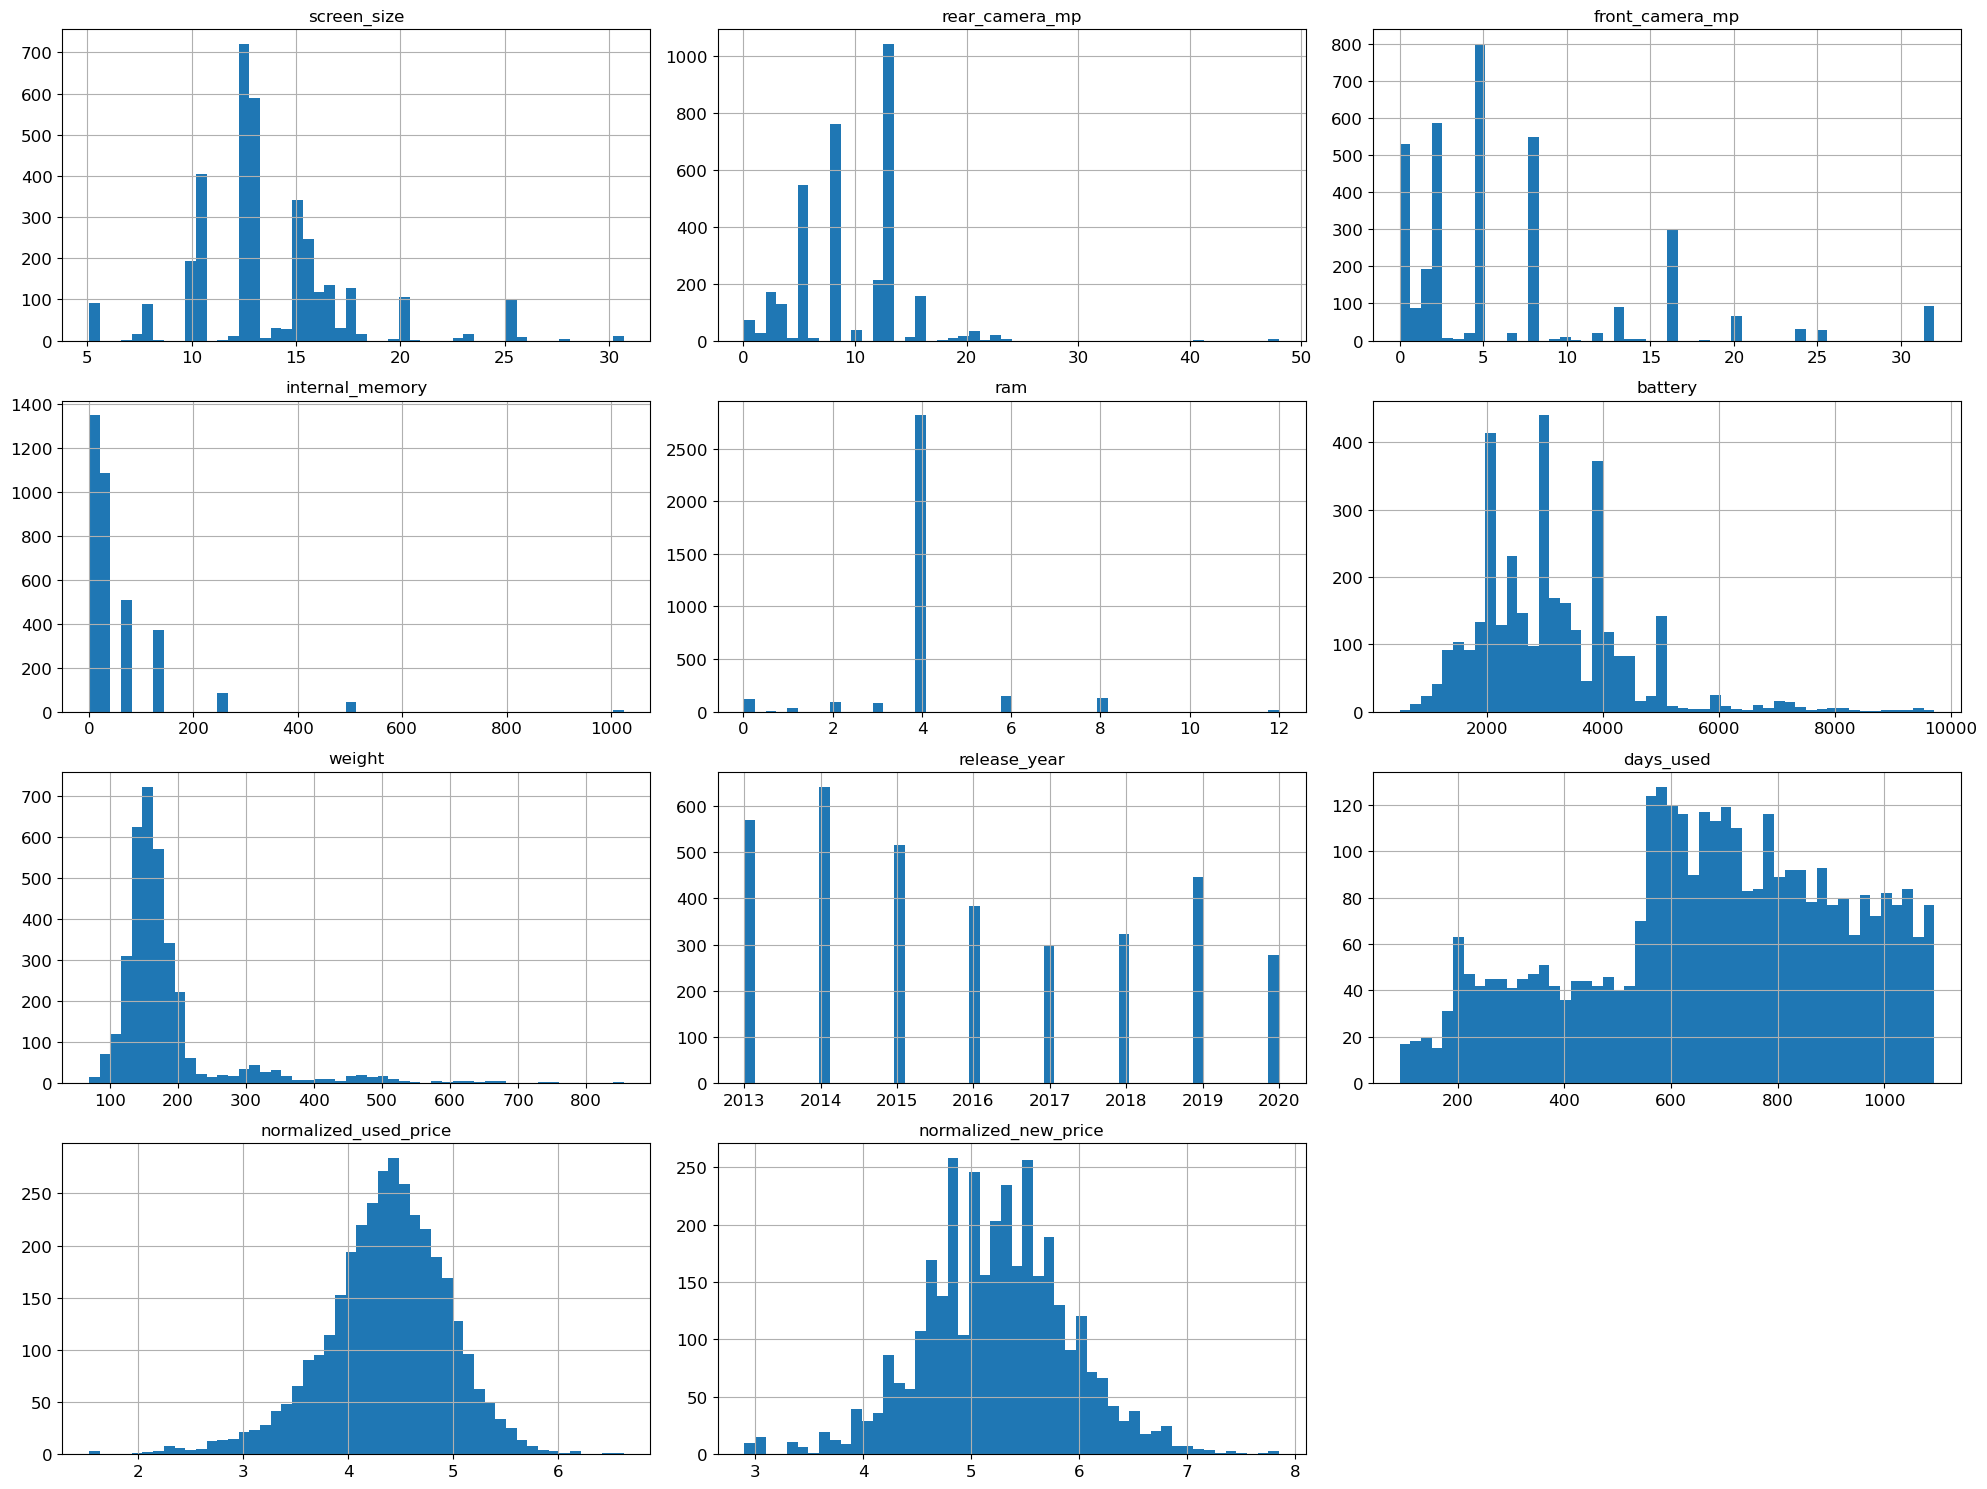

In [132]:
%matplotlib inline
resale.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

## **Creating Test Set**

In [134]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    resale,
    test_size=0.2,
    random_state=42
)

In [135]:
len(train_set)

2763

In [136]:
len(test_set)

691

## **EDA On Train Set**

In [138]:
train_set["normalized_used_price"].describe()

count    2763.000000
mean        4.361376
std         0.593585
min         1.536867
25%         4.029361
50%         4.406597
75%         4.752728
max         6.619433
Name: normalized_used_price, dtype: float64

C:\Users\cp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Saving figure Normalized Used Price Distibution


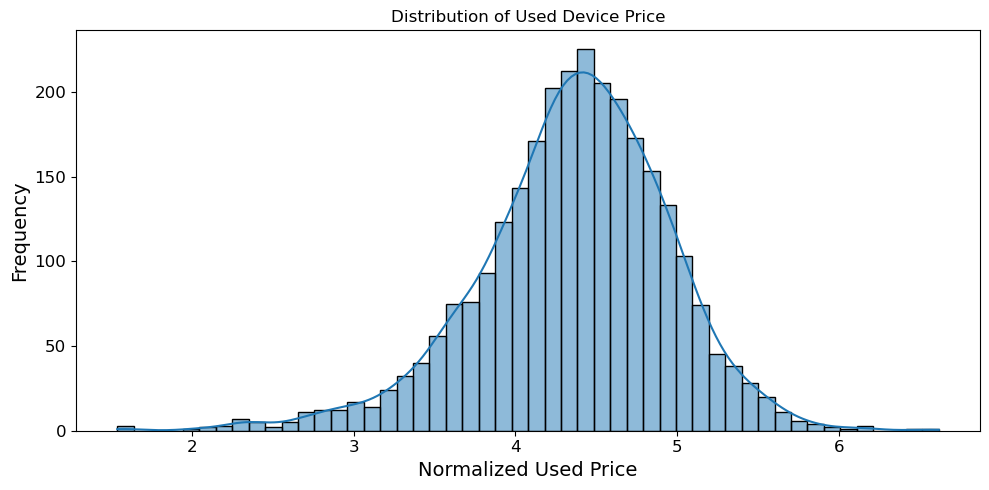

In [139]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_set["normalized_used_price"],
    kde=True
)

plt.title("Distribution of Used Device Price")
plt.xlabel("Normalized Used Price")
plt.ylabel("Frequency")
save_fig("Normalized Used Price Distibution")
plt.show()

The target distribution appears approximately symmetric, with no strong skewness.

#### **Numerical Feature Analysis**

In [140]:
# Correaltion
corr_matrix = train_set.corr(numeric_only = True)
corr_matrix

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
screen_size,1.000000,0.155897,0.271481,0.082476,0.279641,0.815316,0.842165,0.360594,-0.285333,0.621889,0.464049
rear_camera_mp,0.155897,1.000000,0.430931,0.024154,0.260389,0.263055,-0.081450,0.358577,-0.141850,0.590440,0.545347
front_camera_mp,0.271481,0.430931,1.000000,0.296300,0.467698,0.374501,-0.005230,0.689457,-0.547543,0.602511,0.478016
internal_memory,0.082476,0.024154,0.296300,1.000000,0.114334,0.130156,0.023281,0.235434,-0.239215,0.197731,0.204939
ram,0.279641,0.260389,0.467698,0.114334,1.000000,0.284497,0.097135,0.304145,-0.278224,0.517174,0.525230
battery,0.815316,0.263055,0.374501,0.130156,0.284497,1.000000,0.701188,0.491576,-0.371170,0.621123,0.480571
weight,0.842165,-0.081450,-0.005230,0.023281,0.097135,0.701188,1.000000,0.073242,-0.067360,0.390726,0.276105
release_year,0.360594,0.358577,0.689457,0.235434,0.304145,0.491576,0.073242,1.000000,-0.746501,0.504639,0.301888
days_used,-0.285333,-0.141850,-0.547543,-0.239215,-0.278224,-0.371170,-0.067360,-0.746501,1.000000,-0.352252,-0.213249
normalized_used_price,0.621889,0.590440,0.602511,0.197731,0.517174,0.621123,0.390726,0.504639,-0.352252,1.000000,0.835528


Saving figure Correlation


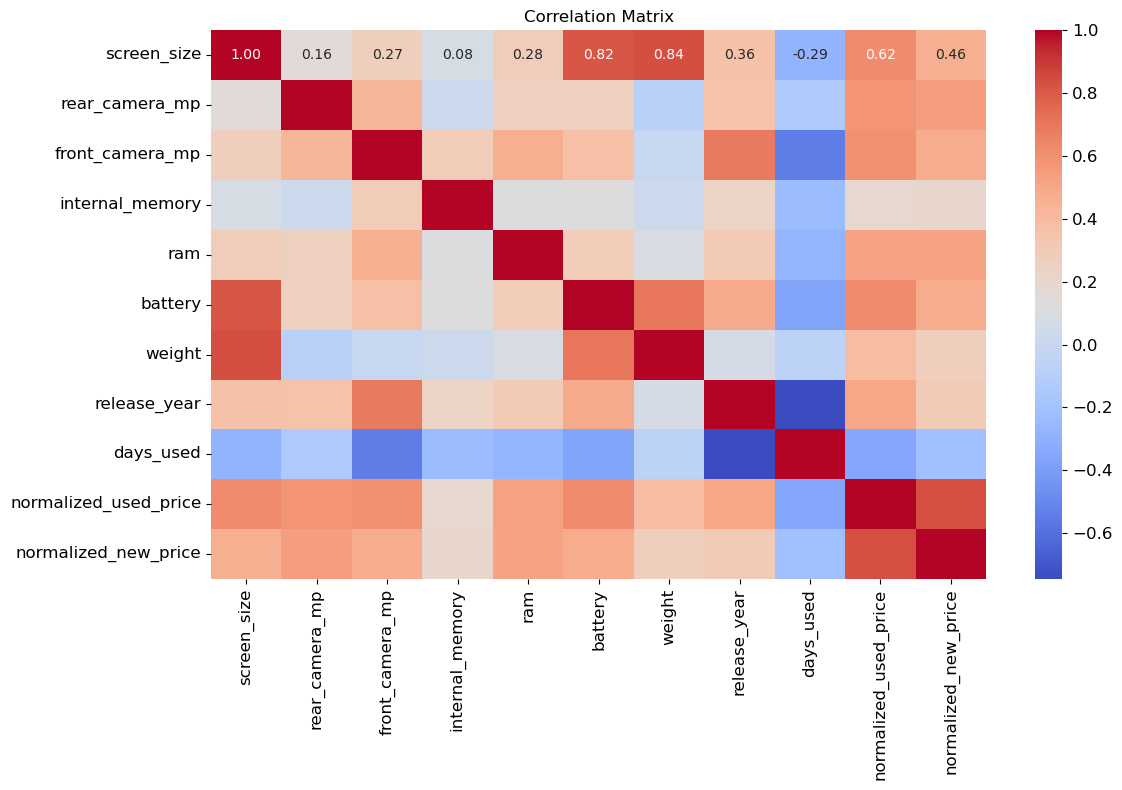

In [165]:
# Correlation graph
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
save_fig("Correlation")
plt.show()

 - **Highly Correlated(>0.50):** Normalized New Price, Screen Size, Battery, Front Camera mp, Rear Camera mp, Ram and Release Year.
 - **Negatively Correlated(<0):** Days Used.
 - **Less Correlated(<0.50):** Weight, Internal Memory.
 - **Multicollinearity flag from correlation matrix:** weight and screen_size are correlated at 0.85, and screen_size/battery at 0.81.

Saving figure New Price vs Used Price


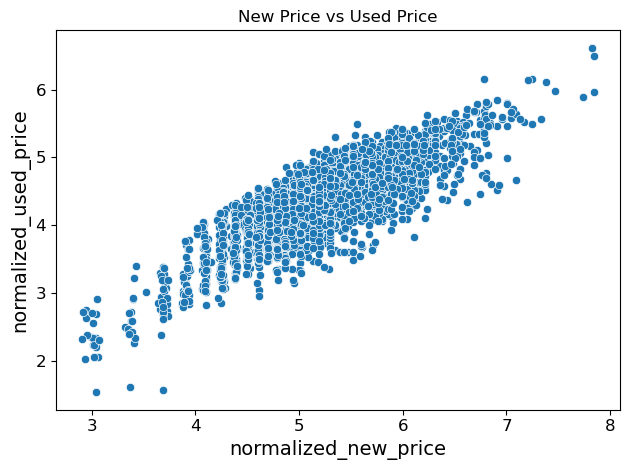

In [141]:
# normalized_used_price vs. normalized_new_price

sns.scatterplot(
    data=train_set,
    x="normalized_new_price",
    y="normalized_used_price"
)

plt.title("New Price vs Used Price")
save_fig("New Price vs Used Price")
plt.show()

Normalized Used Price has strong linear relation with Normalized New Price. It is our strongest predictor by far.

Saving figure Days Used vs Used Price


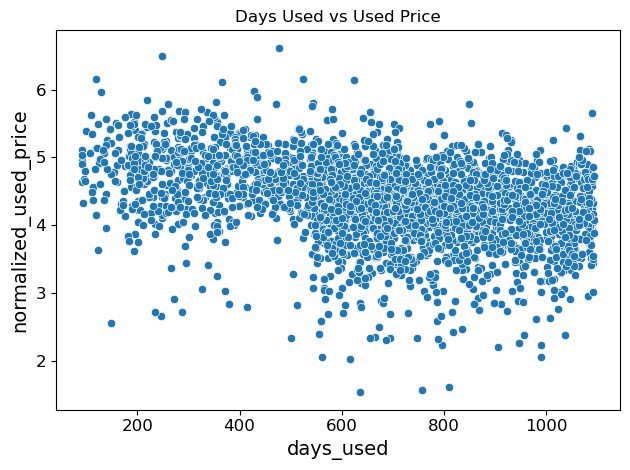

In [142]:
# normalized_used_price vs. days_used

sns.scatterplot(
    data=train_set,
    x="days_used",
    y="normalized_used_price"
)

plt.title("Days Used vs Used Price")
save_fig("Days Used vs Used Price")
plt.show()

Saving figure Release Year vs Used Price


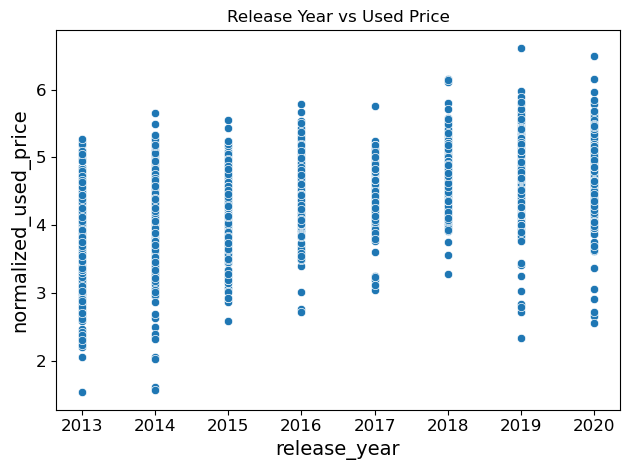

In [143]:
# release_year vs. normalized_new_price

sns.scatterplot(
    data=train_set,
    x="release_year",
    y="normalized_used_price"
)

plt.title("Release Year vs Used Price")
save_fig("Release Year vs Used Price")
plt.show()

#### **Categorical Feature Analysis**

In [188]:
train_set["device_brand"].value_counts()

device_brand
Others        406
Samsung       274
Huawei        205
LG            154
Lenovo        137
ZTE           115
Oppo          108
Xiaomi        102
Honor          99
Asus           99
Micromax       98
Alcatel        92
Vivo           92
Nokia          88
HTC            87
Motorola       84
Sony           73
Meizu          45
XOLO           42
Gionee         38
Acer           37
Panasonic      32
Apple          32
Realme         30
Lava           28
Celkon         26
Karbonn        24
Spice          22
Coolpad        20
Microsoft      19
BlackBerry     18
OnePlus        18
Google         12
Infinix         7
Name: count, dtype: int64

Saving figure Used Price by Device Brand


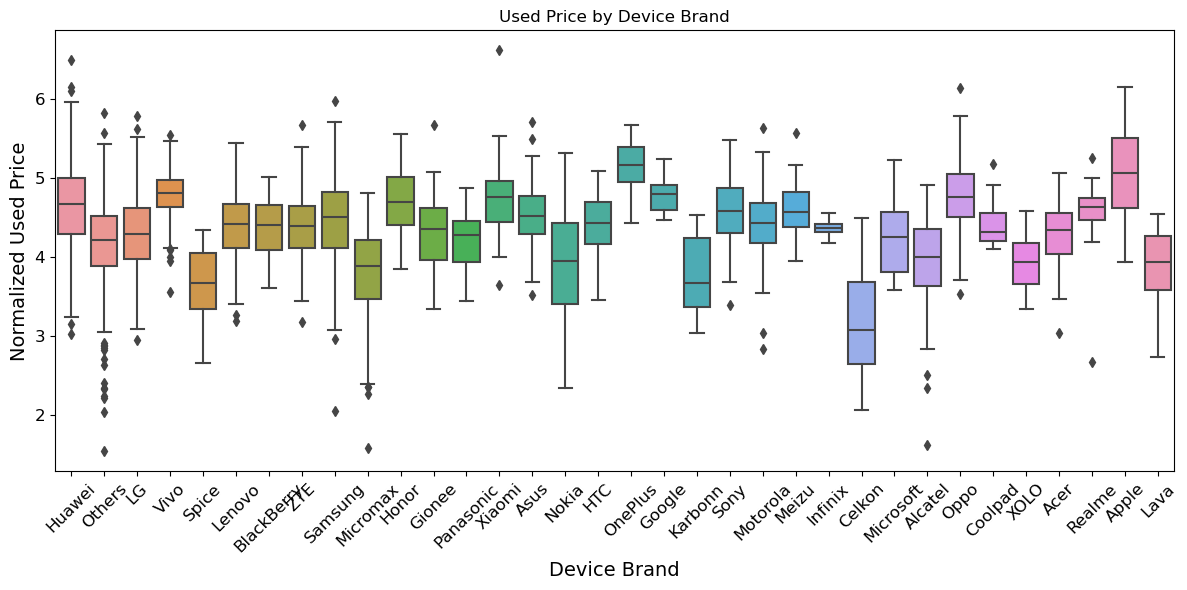

In [170]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=train_set,
    x="device_brand",
    y="normalized_used_price"
)

plt.xticks(rotation=45)
plt.title("Used Price by Device Brand")
plt.xlabel("Device Brand")
plt.ylabel("Normalized Used Price")
save_fig("Used Price by Device Brand")

plt.show()

The boxplot suggests that resale prices vary across brands, with some brands showing higher median used prices than others. However, the distributions also overlap considerably, so brands is not a considerable feature alone to predict resale value.

In [190]:
train_set["os"].value_counts()

os
Android    2565
Others      112
Windows      57
iOS          29
Name: count, dtype: int64

Saving figure Used Price by OS


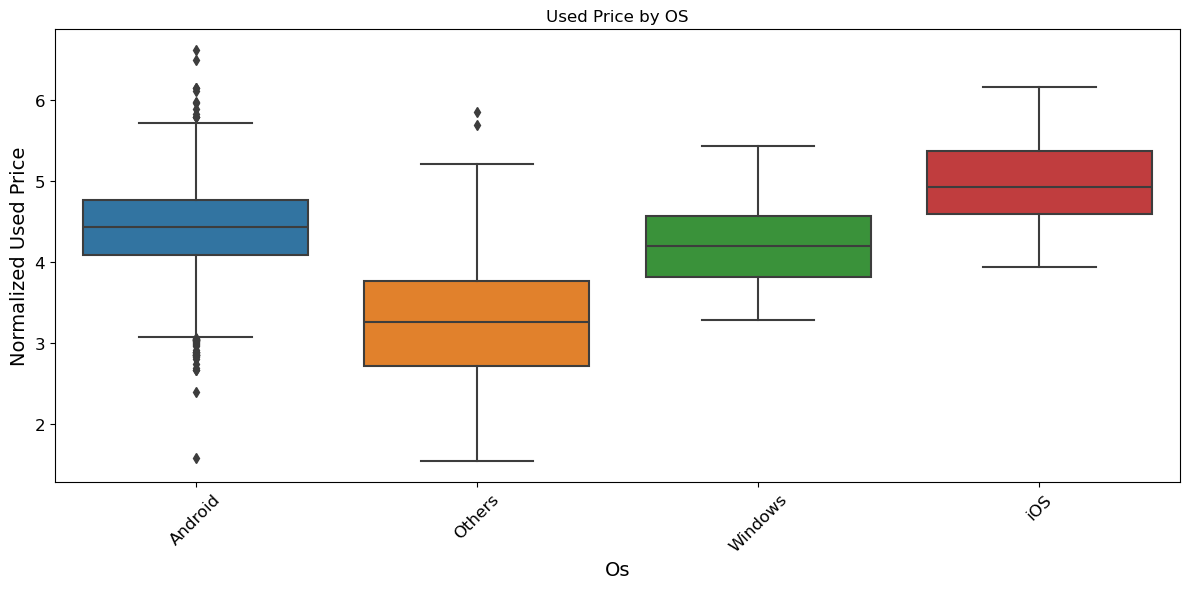

In [172]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=train_set,
    x="os",
    y="normalized_used_price"
)

plt.xticks(rotation=45)
plt.title("Used Price by OS")
plt.xlabel("Os")
plt.ylabel("Normalized Used Price")
save_fig("Used Price by OS")

plt.show()

The boxplot suggests that resale prices vary across os, with some os showing higher median used prices than others. And, the distributions don't overlap considerably, so os can be useful feature  to predict resale value.

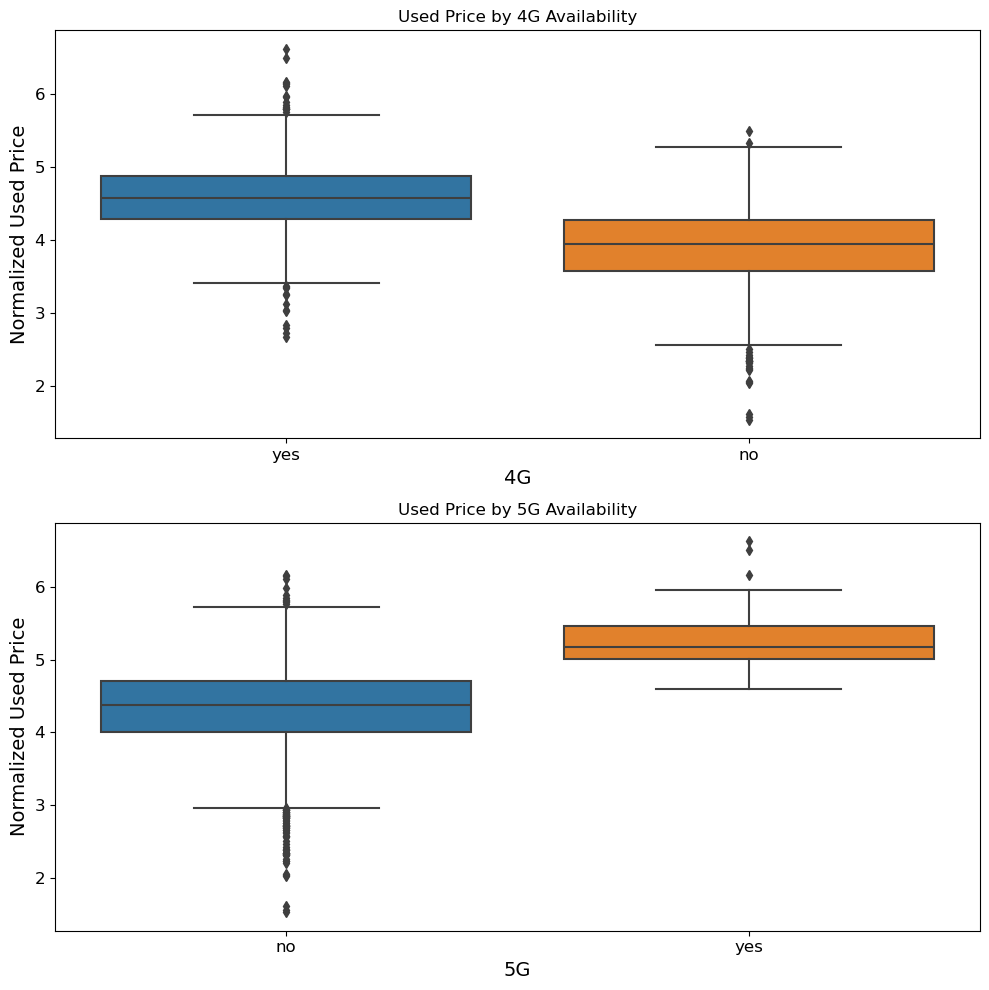

In [182]:
plt.figure(figsize=(10, 10))

# Plot 1 — 4G
plt.subplot(2, 1, 1)

sns.boxplot(
    data=train_set,
    x="4g",
    y="normalized_used_price"
)

plt.title("Used Price by 4G Availability")
plt.xlabel("4G")
plt.ylabel("Normalized Used Price")


# Plot 2 — 5G
plt.subplot(2, 1, 2)

sns.boxplot(
    data=train_set,
    x="5g",
    y="normalized_used_price"
)

plt.title("Used Price by 5G Availability")
plt.xlabel("5G")
plt.ylabel("Normalized Used Price")

plt.tight_layout()
plt.show()

## **Pipeline**

In [200]:
X_train = train_set.drop("normalized_used_price",axis=1)
y_train = train_set["normalized_used_price"].copy()

In [202]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])
cat_pipeline = Pipeline([
        ('cat_imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown="ignore"))
    ])


In [208]:
from sklearn.compose import ColumnTransformer

num_attribs = ["screen_size", "rear_camera_mp", "front_camera_mp", "internal_memory", "ram", "battery",
               "weight", "release_year", "days_used", "normalized_new_price"]

cat_attribs = ["device_brand", "os", "4g","5g"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])


In [216]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_train_prepared.shape

(2763, 52)

## **Select and Train Model**

#### **Baseline Model- Linear Regression(SVD)**

In [220]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

LinearRegression()

In [226]:
lin_reg.intercept_, lin_reg.coef_

(4.304787772256709,
 array([ 0.10816927,  0.10051199,  0.08755414,  0.00787723,  0.03452624,
        -0.02273558,  0.07506671,  0.06070523,  0.0057248 ,  0.29222832,
         0.02060381, -0.04956058,  0.01304879,  0.03256726,  0.04358487,
        -0.1658338 ,  0.02850023, -0.01213658, -0.07242111, -0.0030396 ,
        -0.00384674, -0.02764552,  0.12847485, -0.02678951, -0.03502102,
        -0.00478004,  0.01228042, -0.01333958, -0.03545675,  0.08442872,
        -0.0268835 ,  0.06821764,  0.06450528,  0.00533921, -0.0282271 ,
         0.00514211,  0.09728514, -0.03168721, -0.05325088, -0.01645875,
        -0.02911233, -0.03124313,  0.07899196, -0.01623656,  0.04690248,
        -0.04106141,  0.03044899, -0.03629007, -0.01875513,  0.01875513,
         0.02051814, -0.02051814]))

In [240]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    lin_reg,
    X_train_prepared,
    y_train,
    cv=5,
    scoring=["neg_root_mean_squared_error",
            "neg_mean_absolute_error",
            "r2"]
)

mae = -scores["test_neg_mean_absolute_error"]
rmse_scores = -scores["test_neg_root_mean_squared_error"]
r2 = scores["test_r2"]

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())
print("Mean MAE:", mae.mean())
print("Mean R²:", r2.mean())

RMSE scores: [0.2424923  0.2530806  0.22697146 0.23169235 0.2357033 ]
Mean RMSE: 0.23798800323432615
Std RMSE: 0.009102687078226479
Mean MAE: 0.18430616915888626
Mean R²: 0.8381275333321028


In [242]:
lin_reg_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", LinearRegression())
])

In [244]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lin_reg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

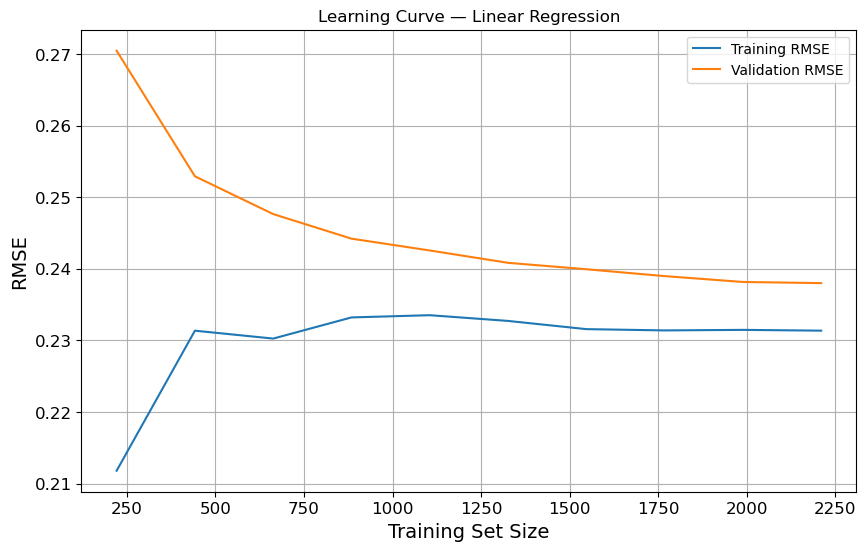

In [246]:
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_rmse, label="Training RMSE")
plt.plot(train_sizes, val_rmse, label="Validation RMSE")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve — Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

The learning curve suggests mild underfitting/high bias. The training and validation RMSE converge to relatively close values, indicating low variance, while the validation error begins to plateau as the training set grows. This suggests that simply adding more data is unlikely to produce a large improvement and that a more expressive model may capture nonlinear relationships that Linear Regression cannot.

#### **Ridge Regression**

In [315]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", Ridge(alpha = 1))
])

In [319]:
scores = cross_validate(
    ridge_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["neg_root_mean_squared_error",
            "neg_mean_absolute_error",
            "r2"]
)

mae = -scores["test_neg_mean_absolute_error"]
rmse_scores = -scores["test_neg_root_mean_squared_error"]
r2 = scores["test_r2"]

print("Mean MAE:", mae.mean())
print("Mean RMSE:", rmse_scores.mean())
print("Mean R²:", r2.mean())

Mean MAE: 0.18402725280476623
Mean RMSE: 0.23770238420656922
Mean R²: 0.8385040375764079


#### **Lasso Regression**

In [321]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model",  Lasso(alpha = 0.01, max_iter=10000))
])

In [323]:
scores = cross_validate(
    lasso_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["neg_root_mean_squared_error",
            "neg_mean_absolute_error",
            "r2"]
)

mae = -scores["test_neg_mean_absolute_error"]
rmse_scores = -scores["test_neg_root_mean_squared_error"]
r2 = scores["test_r2"]

print("Mean MAE:", mae.mean())
print("Mean RMSE:", rmse_scores.mean())
print("Mean R²:", r2.mean())

Mean MAE: 0.18471591946222077
Mean RMSE: 0.2373157117003349
Mean R²: 0.8390606898461932


#### **Decision Tree**

In [303]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model",  DecisionTreeRegressor(random_state=42))
])

In [325]:
scores = cross_validate(
    tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["neg_root_mean_squared_error",
            "neg_mean_absolute_error",
            "r2"]
)

mae = -scores["test_neg_mean_absolute_error"]
rmse_scores = -scores["test_neg_root_mean_squared_error"]
r2 = scores["test_r2"]

print("Mean MAE:", mae.mean())
print("Mean RMSE:", rmse_scores.mean())
print("Mean R²:", r2.mean())

Mean MAE: 0.24044570846537203
Mean RMSE: 0.3157071490627606
Mean R²: 0.7153011851638651


#### **Random Forest**

In [291]:
from sklearn.ensemble import RandomForestRegressor

forest_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

In [293]:
forest_cv = cross_validate(
    forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ],
    n_jobs=-1
)

forest_mae = -forest_cv["test_neg_mean_absolute_error"].mean()
forest_rmse = -forest_cv["test_neg_root_mean_squared_error"].mean()
forest_r2 = forest_cv["test_r2"].mean()

print("Mean MAE:", forest_mae)
print("Mean RMSE:", forest_rmse)
print("Mean R²:", forest_r2)

Mean MAE: 0.18186696220532933
Mean RMSE: 0.2330707912218321
Mean R²: 0.8449014746262093


#### **Gradient Booster**

In [307]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model",GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

In [311]:
gradient_cv = cross_validate(
    gradient_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ],
    n_jobs=-1
)

gradient_mae = -gradient_cv["test_neg_mean_absolute_error"].mean()
gradient_rmse = -gradient_cv["test_neg_root_mean_squared_error"].mean()
gradient_r2 = gradient_cv["test_r2"].mean()

print("Mean MAE:", gradient_mae)
print("Mean RMSE:", gradient_rmse)
print("Mean R²:", gradient_r2)

Mean MAE: 0.17801400747740184
Mean RMSE: 0.22620803894130725
Mean R²: 0.8538519094537487


## **Model Tuning**

Gradient boosting regression and Randon forest are our top 2 picks from the model that we tested.
Linear models plateau around 0.238 (consistent with the high-bias signal out learning curve showed), a single tree overfits badly, and ensembling fixes exactly that — Random Forest and Gradient Boosting both beat every linear model, with boosting edging out bagging.

#### **Grid Search**

In [391]:
# Tuning Gradient booster
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'model__n_estimators': [100, 200, 300],
     'model__learning_rate': [0.03, 0.05, 0.1],
     'model__max_depth': [2, 3, 4, 5, 6],
     'model__min_samples_split': [2, 5],
     'model__min_samples_leaf': [1, 2, 3, 4],
     'model__subsample': [0.7, 0.8, 1.0]}
  ]


grid_search = GridSearchCV(gradient_pipeline, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error',
                           return_train_score=True, n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['screen_size',
                                                                          'rear_camera_mp',
                                                                          'front_camera_mp',
                                                                          'internal_memory',
                                                                          'ram',
                                                                          'battery',
                                                                          'weight',
                                                                          'release_year',
                                                                          'days_used',
                                                                          'normalized_new_price']),
                                                                        ('cat',
                                                                         Pip...
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__learning_rate': [0.03, 0.05, 0.1],
                          'model__max_depth': [2, 3, 4, 5, 6],
                          'model__min_samples_leaf': [1, 2, 3, 4],
                          'model__min_samples_split': [2, 5],
                          'model__n_estimators': [100, 200, 300],
                          'model__subsample': [0.7, 0.8, 1.0]}],
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [393]:
grid_search.best_params_

{'model__learning_rate': 0.03,
 'model__max_depth': 4,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2,
 'model__n_estimators': 200,
 'model__subsample': 1.0}

In [395]:
print("\nBest CV RMSE:")
print(-grid_search.best_score_)


Best CV RMSE:
0.22270098408898004


In [397]:
# Tuning Random Forest
from sklearn.model_selection import GridSearchCV

forest_param_grid = [
    {"model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 6, 7],
    "model__min_samples_leaf": [1, 2, 3],
    "model__max_features": [0.7, 1.0]}
  ]


forest_grid_search = GridSearchCV(forest_pipeline, forest_param_grid, cv=5,
                           scoring='neg_root_mean_squared_error',
                           return_train_score=True, n_jobs=-1)
forest_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['screen_size',
                                                                          'rear_camera_mp',
                                                                          'front_camera_mp',
                                                                          'internal_memory',
                                                                          'ram',
                                                                          'battery',
                                                                          'weight',
                                                                          'release_year',
                                                                          'days_used',
                                                                          'normalized_new_price']),
                                                                        ('cat',
                                                                         Pip...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['device_brand',
                                                                          'os',
                                                                          '4g',
                                                                          '5g'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__max_depth': [None, 10, 20],
                          'model__max_features': [0.7, 1.0],
                          'model__min_samples_leaf': [1, 2, 3],
                          'model__min_samples_split': [2, 5, 6, 7],
                          'model__n_estimators': [100, 200, 300]}],
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [399]:
forest_grid_search.best_params_

{'model__max_depth': 10,
 'model__max_features': 0.7,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 7,
 'model__n_estimators': 200}

In [401]:
print(-forest_grid_search.best_score_)

0.2280081523202254


In [403]:
# Evaluating our best model
best_gradient_pipeline = grid_search.best_estimator_

gradient_cv_final = cross_validate(
    best_gradient_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ],
    n_jobs=-1
)

print("Mean MAE:",
      -gradient_cv_final["test_neg_mean_absolute_error"].mean())

print("Mean RMSE:",
      -gradient_cv_final["test_neg_root_mean_squared_error"].mean())

print("Std RMSE:",
      gradient_cv_final["test_neg_root_mean_squared_error"].std())

print("Mean R²:",
      gradient_cv_final["test_r2"].mean())

Mean MAE: 0.17614437496805052
Mean RMSE: 0.22270098408898004
Std RMSE: 0.006068940869633063
Mean R²: 0.8584476897083521


## **Feature Importance**

In [406]:
best_gradient_model = best_gradient_pipeline.named_steps["model"]

In [408]:
preprocessor = best_gradient_pipeline.named_steps["preprocessing"]

feature_names = preprocessor.get_feature_names_out()

In [410]:
importances = best_gradient_model.feature_importances_

In [412]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,num__normalized_new_price,0.638060
0,num__screen_size,0.145988
3,num__internal_memory,0.085526
2,num__front_camera_mp,0.034499
1,num__rear_camera_mp,0.034265
6,num__weight,0.027451
5,num__battery,0.021726
8,num__days_used,0.003340
7,num__release_year,0.002373
4,num__ram,0.002226


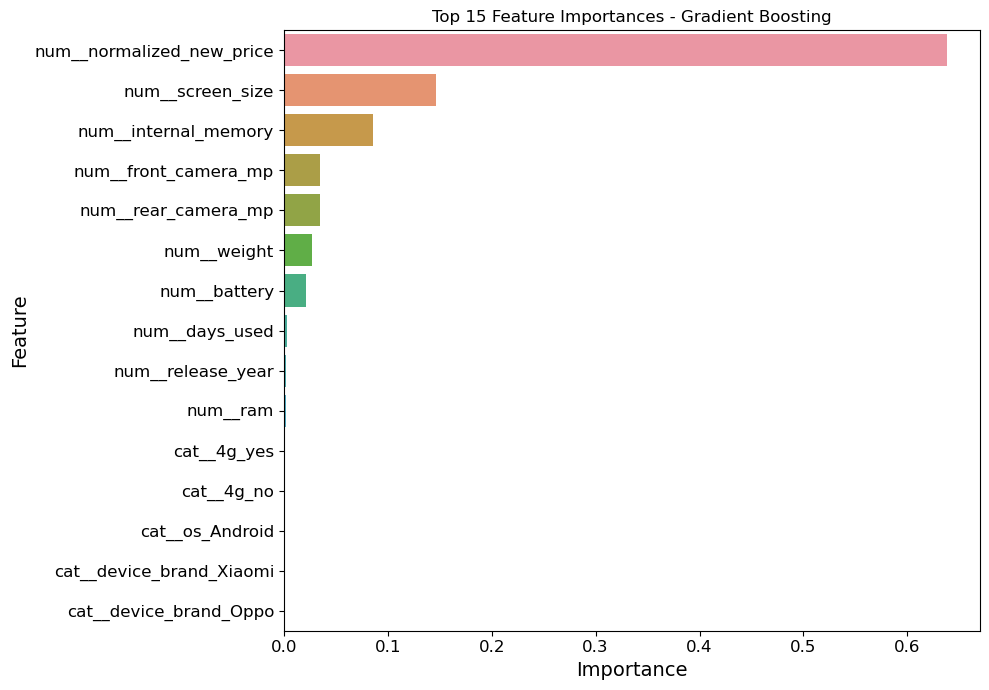

In [414]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## **Evaluate on Test Set**

In [417]:
final_model = grid_search.best_estimator_

X_test = test_set.drop("normalized_used_price",axis=1)
y_test = test_set["normalized_used_price"].copy()


final_predictions = final_model.predict(X_test)

In [419]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_mae = mean_absolute_error(y_test, final_predictions)

test_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

test_r2 = r2_score(y_test,final_predictions)

print("Final Test MAE:", test_mae)
print("Final Test RMSE:", test_rmse)
print("Final Test R²:", test_r2)

Final Test MAE: 0.1752050278328303
Final Test RMSE: 0.2150556967082753
Final Test R²: 0.8574843834206791


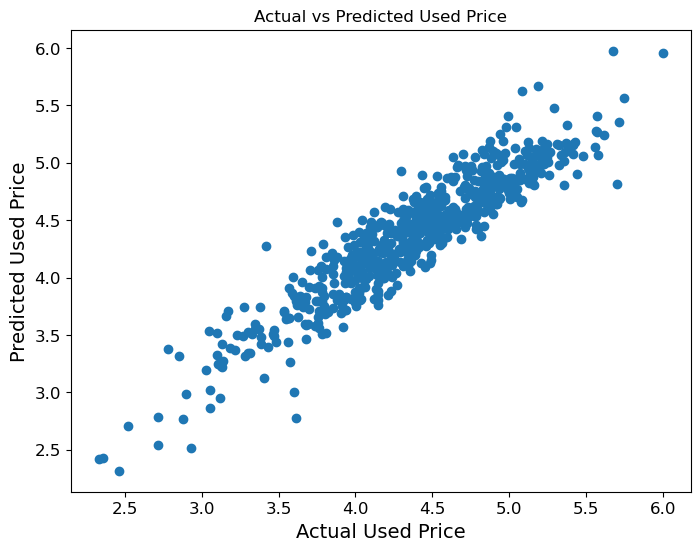

In [421]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, final_predictions)

plt.xlabel("Actual Used Price")
plt.ylabel("Predicted Used Price")
plt.title("Actual vs Predicted Used Price")

plt.show()

The tuned Gradient Boosting Regressor achieved an RMSE of 0.2146, MAE of 0.1732, and R² of 0.8581 on the unseen test set, indicating that the model explains approximately 85.8% of the variation in normalized used-device prices.